# Part 2: ResNet-18 Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [1]:
from pathlib import Path
import importlib
import os
import sys


In [2]:
from pathlib import Path
import importlib
import importlib.util

_REQUIRED_PROJECT_FILES = (
    Path('src/__init__.py'),
    Path('src/utils/notebook_setup.py'),
    Path('src/evaluation/experiment_results.py'),
)

_CANDIDATE_PROJECT_ROOTS = (
    Path('/content/drive/MyDrive/MLDS_Final_Project'),
    Path('/content/MLDS_Final_Project'),
    Path('/content/drive/MyDrive/Colab Notebooks/MLDS_Final_Project'),
)


def _safe_resolve(path):
    try:
        return Path(path).resolve()
    except OSError:
        return None


def _safe_exists(path):
    try:
        return Path(path).exists()
    except OSError:
        return False


def _safe_cwd():
    try:
        return Path.cwd().resolve()
    except OSError:
        fallback = Path('/content')
        return fallback if _safe_exists(fallback) else Path.home()


def _safe_glob(path, pattern):
    try:
        return list(path.glob(pattern))
    except OSError:
        return []


def _path_looks_like_project_root(path):
    try:
        return all((path / required).is_file() for required in _REQUIRED_PROJECT_FILES)
    except OSError:
        return False


def _candidate_project_roots():
    current = _safe_cwd()
    candidates = [current, *current.parents, *_CANDIDATE_PROJECT_ROOTS]
    my_drive = Path('/content/drive/MyDrive')
    if _safe_exists(my_drive):
        candidates.extend(_safe_glob(my_drive, 'MLDS_Final_Project'))
        candidates.extend(_safe_glob(my_drive, '*/MLDS_Final_Project'))
    return candidates


def _find_project_root():
    seen = set()
    for candidate in _candidate_project_roots():
        candidate = _safe_resolve(candidate)
        if candidate is None or candidate in seen:
            continue
        seen.add(candidate)
        if _path_looks_like_project_root(candidate):
            return candidate
    return None


def _mount_colab_drive_if_available():
    try:
        from google.colab import drive  # type: ignore
    except ImportError:
        return
    drive.mount('/content/drive', force_remount=True)


_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT is None:
    _mount_colab_drive_if_available()
    _PROJECT_ROOT = _find_project_root()

if _PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        'Could not find the full MLDS_Final_Project repo. Expected '
        'src/__init__.py, src/utils/notebook_setup.py, and '
        'src/evaluation/experiment_results.py. In Colab, upload or clone '
        'the full repo, or place it at /content/drive/MyDrive/MLDS_Final_Project.'
    )

_COLAB_UTILS_PATH = _PROJECT_ROOT / 'src' / 'utils' / 'colab.py'
_COLAB_SPEC = importlib.util.spec_from_file_location('_mlds_colab_bootstrap', _COLAB_UTILS_PATH)
if _COLAB_SPEC is None or _COLAB_SPEC.loader is None:
    raise ImportError(f'Could not load Colab bootstrap helpers from {_COLAB_UTILS_PATH}')
_colab_bootstrap = importlib.util.module_from_spec(_COLAB_SPEC)
_COLAB_SPEC.loader.exec_module(_colab_bootstrap)

ROOT = _colab_bootstrap.bootstrap_notebook_runtime(_PROJECT_ROOT, force_remount=False)
notebook_setup = importlib.import_module('src.utils.notebook_setup')
ROOT


/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.10.18
Package versions:
  numpy: 1.26.4
  pandas: 2.1.4
  scipy: 1.11.4
  scikit-learn: 1.7.2
  torch: 2.5.1
  torchvision: 0.20.1
  timm: 1.0.26
  pyyaml: 6.0.3
torch.cuda.is_available(): False
Project root: /Users/royrubin/Documents/GitHub/MLDS_Final_Project


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [3]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)


In [4]:
import src.experiments.part2 as part2_experiments

part2_experiments = importlib.reload(part2_experiments)
load_part1_model_baseline_aggregated = experiment_results.load_part1_model_baseline_aggregated
stage_configured_colab_data_dir = experiment_results.stage_configured_colab_data_dir
run_part2_improvement_experiments = part2_experiments.run_part2_improvement_experiments


## Configuration

In [5]:
part2_setup = notebook_setup.setup_part2_config()
config = part2_setup.config
config.stage_colab_data_to_local_disk = True  # Set False on Colab to read directly from Drive instead of copying to /content.
part2_setup.summary['stage_colab_data_to_local_disk'] = config.stage_colab_data_to_local_disk
part2_setup.summary['colab_local_data_dir'] = config.colab_local_data_dir
device = part2_setup.device
output_paths = part2_setup.output_paths
part2_setup.summary


Selected device: cpu
Python: 3.10.18
Package versions:
  numpy: 1.26.4
  pandas: 2.1.4
  scipy: 1.11.4
  scikit-learn: 1.7.2
  torch: 2.5.1
  torchvision: 0.20.1
  timm: 1.0.26
  pyyaml: 6.0.3
torch.cuda.is_available(): False
Selected device: cpu


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,epochs,batch_size,num_workers,use_amp,device
0,part2,part2_improvement,resnet18,"[1, 4]",2,1,16,2,False,cpu


In [ ]:
%%time
config.data_dir = stage_configured_colab_data_dir(config)
print(f'Active data_dir: {config.data_dir}')


In [6]:
pd.DataFrame(config.ablations)

,name,use_pretrained,augmentation,loss,focal_gamma,focal_alpha,curriculum
0,augmentation_patch_shuffle,True,patch_shuffle,NaN,NaN,NaN,NaN
1,augmentation_random_erasing,True,random_erasing,NaN,NaN,NaN,NaN
2,augmentation_same_label_cutmix,True,same_label_cutmix,NaN,NaN,NaN,NaN
3,loss_focal_loss,True,none,focal_loss,2.0,1.0,NaN
4,curriculum_corruption_probability,True,none,NaN,NaN,NaN,corruption_probability
5,curriculum_permutation_difficulty,True,none,NaN,NaN,NaN,permutation_difficulty


## Part 1 ResNet-18 Baseline

In [7]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,ablation_name,config_name
0,resnet18,4.0,16,0.903846,0.0,0.903846,0.0,2,regular_part1,part2_improvement
1,resnet18,NaN,1,0.865385,NaN,0.865385,NaN,1,regular_part1,part2_improvement


## Train Improvement Ablations

In [8]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(config=config, device=device)
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')

Raw results path: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_raw_results.csv
Checkpointing disabled outside Google Colab.
Saved 18 pending row(s) for model 'resnet18'.

Running ablation: augmentation_patch_shuffle

[1/3]
model=resnet18, ablation=augmentation_patch_shuffle, tiles_per_side=None, tile_permutation_id=0, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=11,177,538, optimizer_params=11,177,538, freeze_backbone=False


resnet18 [augmentation_patch_shuffle] 1x1 permutation #0. epochs progress:   0%|          | 0/1 [00:00<?, ?epoch/s]

First batch: tensor_device=cpu, tensor_shape=(16, 3, 225, 225)


resnet18 [augmentation_patch_shuffle] 1x1 permutation #0. epochs progress: 100%|██████████| 1/1 [00:48<00:00, 48.20s/epoch, best_val_accuracy=0.942, stage=standard, train_accuracy=0.809, train_loss=0.38, val_accuracy=0.942, val_loss=0.221]


Current run runtime: 48s
Total training runtime: 49s

[2/3]
model=resnet18, ablation=augmentation_patch_shuffle, tiles_per_side=4, tile_permutation_id=1, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...
Runtime: selected_device=cpu, model_device=cpu, use_amp=False, amp_enabled=False, cuda_device=None
Model summary: model=resnet18, total_params=11,177,538, trainable_params=11,177,538, optimizer_params=11,177,538, freeze_backbone=False


...

resnet18 [curriculum_permutation_difficulty] 4x4 permutation #2. epochs progress:   0%|          | 0/4 [00:00<?, ?epoch/s]

First batch: tensor_device=cpu, tensor_shape=(16, 3, 224, 224)


resnet18 [curriculum_permutation_difficulty] 4x4 permutation #2. epochs progress: 100%|██████████| 4/4 [03:09<00:00, 47.44s/epoch, best_val_accuracy=0.885, stage=4x4_permutation, train_accuracy=0.922, train_loss=0.216, val_accuracy=0.846, val_loss=0.698] 


Current run runtime: 3m 10s
Total training runtime: 32m 25s


,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_patch_shuffle,4.0,16,0.846154,0.000000,0.846154,0.000000,2
1,resnet18,augmentation_patch_shuffle,NaN,1,0.942308,NaN,0.942308,NaN,1
2,resnet18,augmentation_random_erasing,4.0,16,0.836538,0.013598,0.836538,0.013598,2
3,resnet18,augmentation_random_erasing,NaN,1,0.826923,NaN,0.826923,NaN,1
4,resnet18,augmentation_same_label_cutmix,4.0,16,0.817308,0.122384,0.817308,0.122384,2
5,resnet18,augmentation_same_label_cutmix,NaN,1,0.961538,NaN,0.961538,NaN,1
6,resnet18,curriculum_corruption_probability,4.0,16,0.884615,0.054393,0.903846,0.027196,2
7,resnet18,curriculum_corruption_probability,NaN,1,0.923077,NaN,0.923077,NaN,1
8,resnet18,curriculum_permutation_difficulty,4.0,16,0.817308,0.040795,0.855769,0.040795,2
9,resnet18,curriculum_permutation_difficulty,NaN,1,0.903846,NaN,0.903846,NaN,1


## Results

In [9]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['tiles_per_side', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet-18 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_patch_shuffle,4.0,16,0.846154,0.000000,0.846154,0.000000,2
2,resnet18,augmentation_random_erasing,4.0,16,0.836538,0.013598,0.836538,0.013598,2
4,resnet18,augmentation_same_label_cutmix,4.0,16,0.817308,0.122384,0.817308,0.122384,2
6,resnet18,curriculum_corruption_probability,4.0,16,0.884615,0.054393,0.903846,0.027196,2
8,resnet18,curriculum_permutation_difficulty,4.0,16,0.817308,0.040795,0.855769,0.040795,2
10,resnet18,loss_focal_loss,4.0,16,0.846154,0.000000,0.846154,0.000000,2
12,resnet18,regular_part1,4.0,16,0.903846,0.000000,0.903846,0.000000,2
1,resnet18,augmentation_patch_shuffle,NaN,1,0.942308,NaN,0.942308,NaN,1
3,resnet18,augmentation_random_erasing,NaN,1,0.826923,NaN,0.826923,NaN,1
5,resnet18,augmentation_same_label_cutmix,NaN,1,0.961538,NaN,0.961538,NaN,1


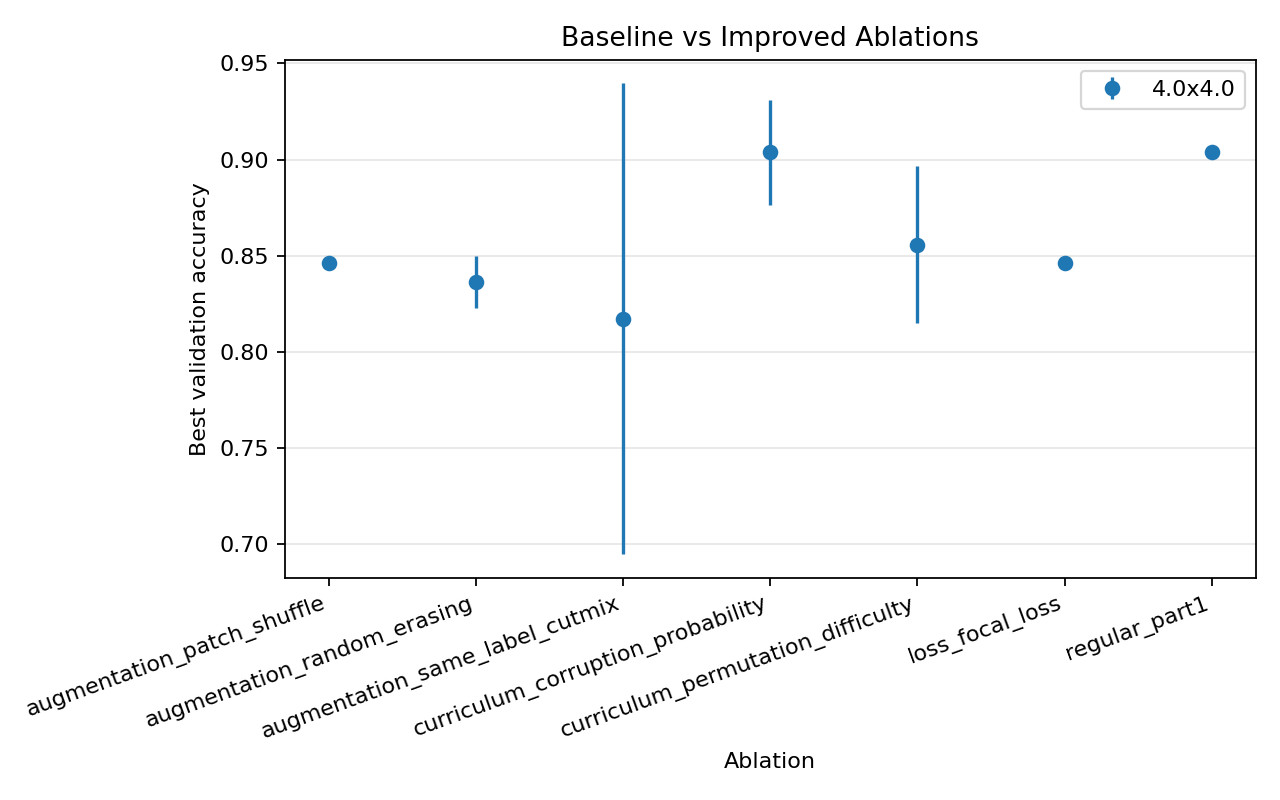

In [10]:
figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')

In [11]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import subprocess

notebook_path = ROOT / 'src' / 'notebooks' / 'part2_solution.ipynb'
export_dir = ROOT / 'outputs' / 'notebooks'
export_dir.mkdir(parents=True, exist_ok=True)

try:
    subprocess.run(
        [
            sys.executable,
            '-m',
            'jupyter',
            'nbconvert',
            '--to',
            'pdf',
            str(notebook_path),
            '--output-dir',
            str(export_dir),
        ],
        check=True,
    )
    print(f'Generated PDF: {export_dir / notebook_path.with_suffix(".pdf").name}')
except subprocess.CalledProcessError as exc:
    print('PDF export failed. Confirm the notebook is saved and that nbconvert plus LaTeX are installed.')
    print(f'Command exited with status {exc.returncode}.')


[NbConvertApp] Converting notebook /Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/notebooks/part2_solution.ipynb to pdf
[NbConvertApp] Writing 39725 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']


Generated PDF: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/part2_solution.pdf


[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 45262 bytes to /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/part2_solution.pdf
